# **Threshold 확정 + 자세 판단 및 피드백**



## 데이터 불러오기 및 설정

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

In [6]:
from pathlib import Path

# 데이터 디렉토리 후보 경로들 (탐색용)
DATA_DIR_CANDIDATES = [
    Path("data/datasets"),
    Path("../datasets"),        # data/analysis 환경에서 사용
    Path("../../data/datasets"),
    Path("/content"),           # Colab 환경
]

# 각 후보 경로에서 dataset_good_1.npz 파일 존재 여부 확인
for candidate in DATA_DIR_CANDIDATES:
    if (candidate / "dataset_good_1.npz").exists():
        DATA_DIR = candidate  # 실제 데이터 디렉토리로 확정
        break
else:
    # 모든 후보 경로에서 파일을 찾지 못한 경우 예외 발생
    raise FileNotFoundError("dataset_good_1.npz 파일을 찾을 수 없습니다. DATA_DIR 경로를 확인하세요.")

print(f"DATA_DIR: {DATA_DIR.resolve()}")  # 최종 선택된 데이터 경로 출력

data_good = []  # 데이터 저장 리스트 초기화
for i in range(1, 5):
    # dataset_good_i.npz 파일 로드
    data = np.load(DATA_DIR / f"dataset_good_{i}.npz")
    data_good.append(data)  # 리스트에 추가

DATA_DIR: /content


In [7]:
data_good

[NpzFile '/content/dataset_good_1.npz' with keys: sequences, labels,
 NpzFile '/content/dataset_good_2.npz' with keys: sequences, labels,
 NpzFile '/content/dataset_good_3.npz' with keys: sequences, labels,
 NpzFile '/content/dataset_good_4.npz' with keys: sequences, labels]

In [8]:
data_bad = np.load(DATA_DIR / "dataset_bad_1.npz")


In [9]:
data_bad

NpzFile '/content/dataset_bad_1.npz' with keys: sequences, labels

`num_features` - feature 개수를 나타내는 변수

`feature_context`  - feature의 내용을 나타내는 딕셔너리

In [10]:
# feature 개수
num_features = 6

In [11]:
feature_context = {
    0: '왼손목-왼어깨 거리',
    1: '양쪽 팔꿈치 거리',
    2: '왼손목 속도',
    3: '왼팔 각도',
    4: '오른팔 각도',
    5: '오른손목 각도'
}

In [12]:
feature_context[0]

'왼손목-왼어깨 거리'

`all_seq_good` - 전체 좋은 자세 데이터셋

`seq_good`  - 1개의 좋은 자세 데이터셋

In [13]:
all_seq_good = np.concatenate(
    [data_good[i]['sequences'] for i in range(4)],
    axis=0
)

all_seq_good.shape # (548*4, 30, 6)


(2743, 30, 6)

In [14]:
seq_good = data_good[0]['sequences']
seq_good

array([[[2.0859554e-01, 3.5257137e-01, 2.6717852e-03, 4.2829861e+01,
         2.9796011e+01, 1.6600162e+02],
        [2.0727530e-01, 3.5843712e-01, 6.3225912e-04, 4.2032024e+01,
         2.9986713e+01, 1.6701152e+02],
        [2.0685612e-01, 3.7626326e-01, 2.4106103e-04, 4.1958458e+01,
         7.5007149e+01, 1.4582460e+02],
        ...,
        [1.9098088e-01, 3.6362013e-01, 1.5909479e-04, 3.8577003e+01,
         4.3485294e+01, 1.7550623e+02],
        [1.9118676e-01, 3.6546034e-01, 8.5371918e-05, 3.8551006e+01,
         6.1369057e+01, 1.3735817e+02],
        [1.9275945e-01, 3.4988800e-01, 3.2315220e-04, 3.8991386e+01,
         3.9470348e+01, 1.7984354e+02]],

       [[2.0859554e-01, 3.5257137e-01, 2.6717852e-03, 4.2829861e+01,
         2.9796011e+01, 1.6600162e+02],
        [2.0727530e-01, 3.5843712e-01, 6.3225912e-04, 4.2032024e+01,
         2.9986713e+01, 1.6701152e+02],
        [2.0685612e-01, 3.7626326e-01, 2.4106103e-04, 4.1958458e+01,
         7.5007149e+01, 1.4582460e+02],
    

In [15]:
seq_bad = data_bad['sequences']

## Feature별 분석 및 threshold 설정

- **거리 기반 feature** (왼손목-왼어깨, 양쪽 팔꿈치)

연주자의 체격에 따라 달라질 수 있어 신체 비율로 정규화 고려.
`왼손목-왼어깨` 포지션 이동 시를 제외하고 일정 범위를 유지해야 한다. `양쪽 팔꿈치` 보잉 시 이 거리가 급격히 좁아지거나 넓어지면 자세가 무너진 것(ex. 정상 범위의 15% 이탈 시 경고)으로 판단한다.

- **각도 기반 feature** (왼팔, 오른팔, 오른손목)

`오른팔/오른손목` 활의 위치에 따라 이상적인 각도 경로가 존재한다.

정적: 오른팔 각도가 160도를 넘어가면 팔을 과하게 폈다는 식의 hard threshold를 설정할 수 있다.

- **속도 기반 feature** (왼손목 속도)

포지션 이동이 없는 구간에서 속도가 일정 임계값을 넘으면 불필요한 흔들림으로 간주한다.

➡️ window median + IQR 이상치 제거 + good/bad 분리 threshold 방식으로 진행.

In [16]:
# 30길이 시퀀스를 하나의 feature vector로 요약하는 함수
# 평균/중앙값/최댓값 등 여러 통계값 기반으로 시계열 정보를 압축
# 각 시점의 변동을 하나의 대표값으로 변환하여 모델 입력으로 사용 가능
def summarize_sequence(sequence):
    """
    sequence: shape (30, 6) 또는 (N, 30, 6)
    return : shape (6,) 또는 (N, 6)
    """
    sequence = np.asarray(sequence)
    return np.median(sequence, axis=-2)  # 시간 축 기준 중앙값 계산

# 정상 데이터 시퀀스를 하나의 요약 feature로 변환
good_summary = summarize_sequence(all_seq_good)

# 비정상(또는 비교 대상) 시퀀스를 동일 방식으로 요약
bad_summary = summarize_sequence(seq_bad)

In [17]:
good_summary

array([[1.9481550e-01, 3.7792331e-01, 3.0180492e-04, 3.8152618e+01,
        5.1025448e+01, 1.5915645e+02],
       [1.9481550e-01, 3.7792331e-01, 3.0180492e-04, 3.8152618e+01,
        5.1025448e+01, 1.5915645e+02],
       [1.9481550e-01, 3.7792331e-01, 3.0180492e-04, 3.8152618e+01,
        5.1025448e+01, 1.5915645e+02],
       ...,
       [1.1309273e-01, 5.3669357e-01, 0.0000000e+00, 2.4741554e+01,
        2.0279526e+01, 1.5122028e+02],
       [1.1309273e-01, 5.3669357e-01, 0.0000000e+00, 2.4741554e+01,
        2.0279526e+01, 1.5122028e+02],
       [1.1309273e-01, 5.3669357e-01, 0.0000000e+00, 2.4741554e+01,
        2.0279526e+01, 1.5122028e+02]], dtype=float32)

In [18]:
# 이상치 제거 함수
def remove_iqr_outliers_1d(x, k=1.5):
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    lo = q1 - k * iqr
    hi = q3 + k * iqr
    return x[(x >= lo) & (x <= hi)]

# best threshold 탐색 함수
def find_best_threshold(good_values, bad_values):
    values = np.concatenate([good_values, bad_values])
    labels = np.concatenate([
        np.zeros(len(good_values)),
        np.ones(len(bad_values))
    ])

    candidates = np.unique(values)
    candidates = (candidates[:-1] + candidates[1:]) / 2

    best = None

    for direction in [">=", "<="]:
        for t in candidates:
            pred = values >= t if direction == ">=" else values <= t

            tp = np.sum((pred == 1) & (labels == 1))
            tn = np.sum((pred == 0) & (labels == 0))
            fp = np.sum((pred == 1) & (labels == 0))
            fn = np.sum((pred == 0) & (labels == 1))

            recall_bad = tp / (tp + fn) if tp + fn > 0 else 0
            specificity_good = tn / (tn + fp) if tn + fp > 0 else 0
            accuracy = (tp + tn) / len(labels)

            score = recall_bad + specificity_good - 1

            result = {
                "threshold": t,
                "direction": direction,
                "accuracy": accuracy,
                "bad_recall": recall_bad,
                "good_specificity": specificity_good,
                "fp": fp,
                "fn": fn,
                "score": score,
            }

            if best is None or result["score"] > best["score"]:
                best = result

    return best

In [19]:
thresholds = {}

for feature_idx, name in feature_context.items():
    good_clean = remove_iqr_outliers_1d(good_summary[:, feature_idx])
    bad_clean = remove_iqr_outliers_1d(bad_summary[:, feature_idx])

    result = find_best_threshold(good_clean, bad_clean)
    thresholds[feature_idx] = result

    print(f"[{feature_idx}] {name}")
    print(f"direction: {result['direction']}, threshold: {result['threshold']}")
    print()

[0] 왼손목-왼어깨 거리
direction: >=, threshold: 0.2884293496608734

[1] 양쪽 팔꿈치 거리
direction: <=, threshold: 0.47038209438323975

[2] 왼손목 속도
direction: >=, threshold: 0.00017041372484527528

[3] 왼팔 각도
direction: >=, threshold: 91.1182861328125

[4] 오른팔 각도
direction: >=, threshold: 133.29283142089844

[5] 오른손목 각도
direction: >=, threshold: 166.97837829589844



In [20]:
thresholds

{0: {'threshold': np.float32(0.28842935),
  'direction': '>=',
  'accuracy': np.float64(1.0),
  'bad_recall': np.float64(1.0),
  'good_specificity': np.float64(1.0),
  'fp': np.int64(0),
  'fn': np.int64(0),
  'score': np.float64(1.0)},
 1: {'threshold': np.float32(0.4703821),
  'direction': '<=',
  'accuracy': np.float64(0.6191393705844573),
  'bad_recall': np.float64(1.0),
  'good_specificity': np.float64(0.5676266861100985),
  'fp': np.int64(1186),
  'fn': np.int64(0),
  'score': np.float64(0.5676266861100985)},
 2: {'threshold': np.float32(0.00017041372),
  'direction': '>=',
  'accuracy': np.float64(0.7847334410339257),
  'bad_recall': np.float64(0.8382749326145552),
  'good_specificity': np.float64(0.7752969121140143),
  'fp': np.int64(473),
  'fn': np.int64(60),
  'score': np.float64(0.6135718447285696)},
 3: {'threshold': np.float32(91.118286),
  'direction': '>=',
  'accuracy': np.float64(1.0),
  'bad_recall': np.float64(1.0),
  'good_specificity': np.float64(1.0),
  'fp': np.

이 중 지금 데이터에서는 0, 3, 4, 5번 feature가 threshold로 쓰기 좋고, 1, 2번은 good/bad가 많이 겹쳐서 단독 판단 기준으로는 약하다.

In [21]:
good_clean

array([159.15645, 159.15645, 159.15645, ..., 151.22028, 151.22028,
       151.22028], dtype=float32)

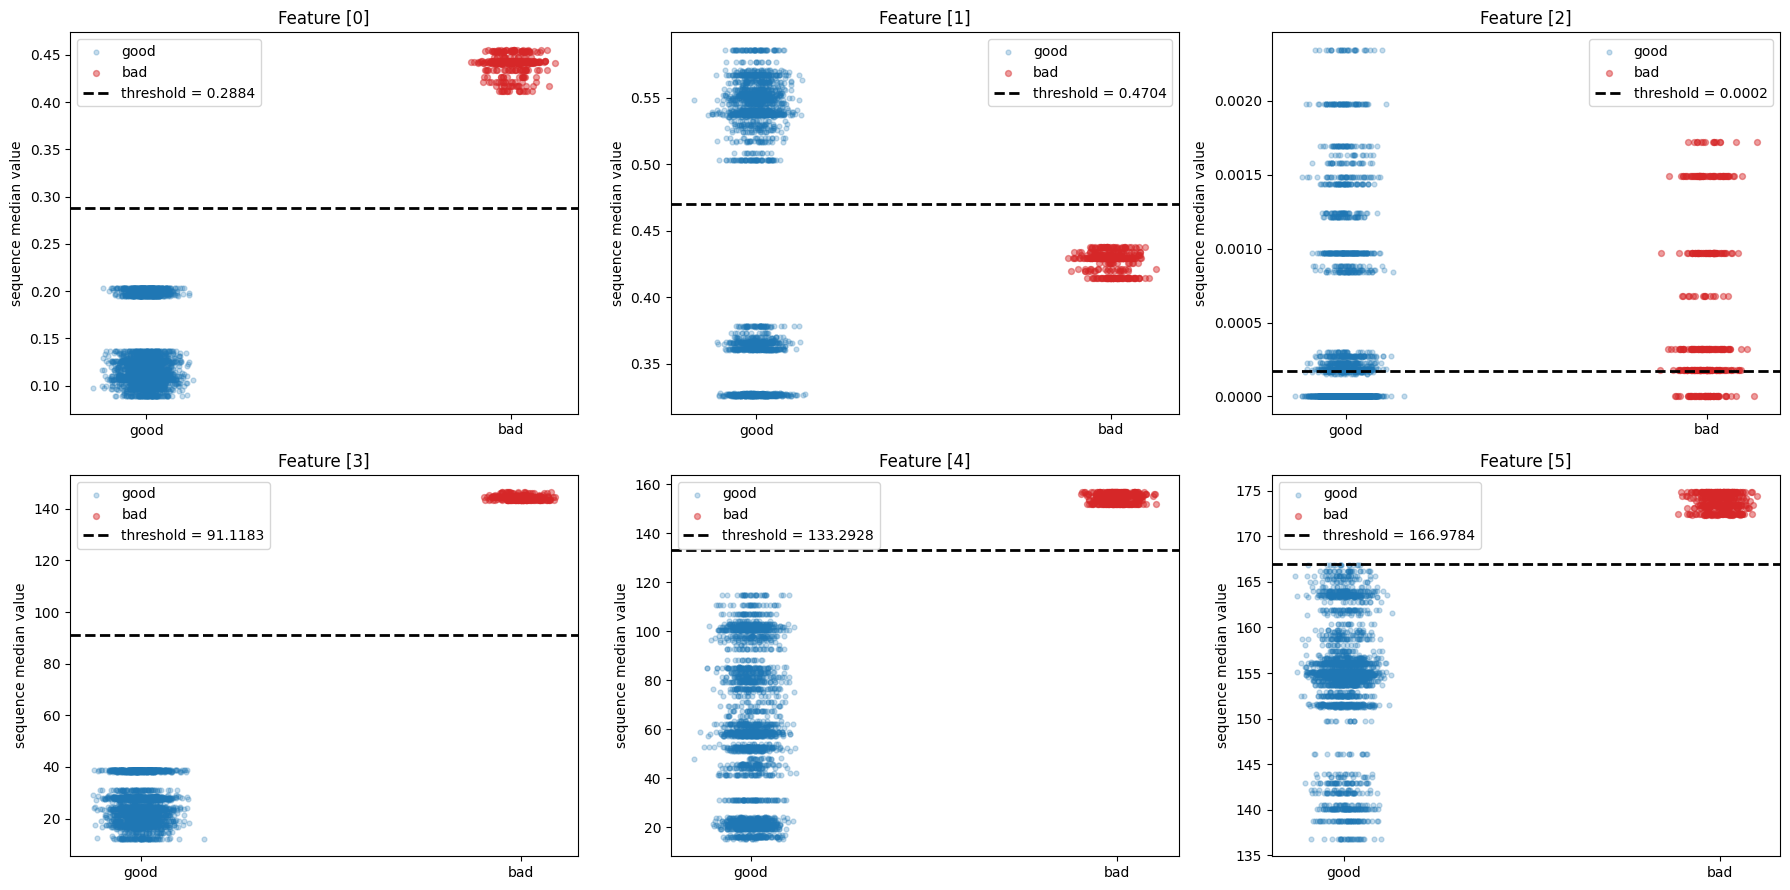

In [22]:
# 각 sequence를 점으로 찍고 threshold를 가로선으로 표시한다.
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

rng = np.random.default_rng(42)

for ax, feature_idx in zip(axes, feature_context):
    threshold = thresholds[feature_idx]['threshold']
    good_values = good_summary[:, feature_idx]
    bad_values = bad_summary[:, feature_idx]

    good_x = rng.normal(0, 0.04, size=len(good_values))
    bad_x = rng.normal(1, 0.04, size=len(bad_values))

    ax.scatter(good_x, good_values, s=12, alpha=0.25, color='tab:blue', label='good')
    ax.scatter(bad_x, bad_values, s=18, alpha=0.45, color='tab:red', label='bad')
    ax.axhline(
        threshold,
        color='black',
        linestyle='--',
        linewidth=2,
        label=f"threshold = {threshold:.4f}",
    )

    ax.set_title(f"Feature [{feature_idx}]")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['good', 'bad'])
    ax.set_ylabel('sequence median value')
    ax.legend()

plt.tight_layout()
plt.show()

In [23]:
# feature 2개로 조합하여 decision boundary 그리기

X_summary = np.vstack([good_summary, bad_summary])
y_summary = np.concatenate([
    np.zeros(len(good_summary), dtype=int),
    np.ones(len(bad_summary), dtype=int),
])

def iqr_mask_2d(x, k=1.5):
    q1 = np.percentile(x, 25, axis=0)
    q3 = np.percentile(x, 75, axis=0)
    iqr = q3 - q1
    lo = q1 - k * iqr
    hi = q3 + k * iqr
    return ((x >= lo) & (x <= hi)).all(axis=1)

def plot_decision_boundary(feature_x, feature_y, model_type='linear', remove_outliers=True):
    good_xy = good_summary[:, [feature_x, feature_y]]
    bad_xy = bad_summary[:, [feature_x, feature_y]]

    if remove_outliers:
        good_xy = good_xy[iqr_mask_2d(good_xy)]
        bad_xy = bad_xy[iqr_mask_2d(bad_xy)]

    X = np.vstack([good_xy, bad_xy])
    y = np.concatenate([
        np.zeros(len(good_xy), dtype=int),
        np.ones(len(bad_xy), dtype=int),
    ])

    if model_type == 'linear':
        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(class_weight='balanced', max_iter=1000),
        )
        title_prefix = 'Linear boundary'
    elif model_type == 'quadratic':
        model = make_pipeline(
            StandardScaler(),
            PolynomialFeatures(degree=2, include_bias=False),
            LogisticRegression(class_weight='balanced', max_iter=1000),
        )
        title_prefix = 'Quadratic boundary'
    else:
        raise ValueError("model_type은 'linear' 또는 'quadratic'만 사용할 수 있습니다.")

    model.fit(X, y)

    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()
    x_margin = (x_max - x_min) * 0.08
    y_margin = (y_max - y_min) * 0.08

    xx, yy = np.meshgrid(
        np.linspace(x_min - x_margin, x_max + x_margin, 300),
        np.linspace(y_min - y_margin, y_max + y_margin, 300),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    proba = model.predict_proba(grid)[:, 1].reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, proba, levels=20, cmap='RdBu_r', alpha=0.2)
    plt.contour(xx, yy, proba, levels=[0.5], colors='black', linewidths=2)
    plt.scatter(good_xy[:, 0], good_xy[:, 1], s=14, alpha=0.35, color='tab:blue', label='good')
    plt.scatter(bad_xy[:, 0], bad_xy[:, 1], s=20, alpha=0.55, color='tab:red', label='bad')
    plt.xlabel(f"Feature [{feature_x}]")
    plt.ylabel(f"Feature [{feature_y}]")
    plt.title(f"{title_prefix}: {feature_x} vs {feature_y}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    pred = model.predict(X)
    pred_proba = model.predict_proba(X)[:, 1]

    auc = roc_auc_score(y, pred_proba)

    cv_auc = cross_val_score(
      model,
      X,
      y,
      cv=5,
      scoring='roc_auc'
    )

    print('train accuracy:', model.score(X, y))
    print("Train ROC-AUC:", auc)
    print("CV ROC-AUC mean:", cv_auc.mean())
    print("CV ROC-AUC std:", cv_auc.std())

    print(confusion_matrix(y, pred))
    print(classification_report(y, pred))

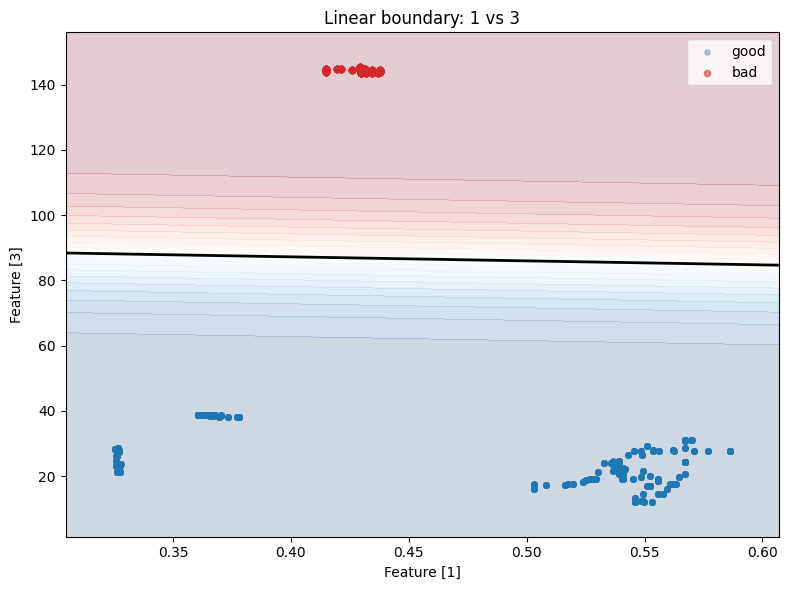

train accuracy: 1.0
Train ROC-AUC: 0.9999999999999999
CV ROC-AUC mean: 1.0
CV ROC-AUC std: 0.0
[[2743    0]
 [   0  345]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2743
           1       1.00      1.00      1.00       345

    accuracy                           1.00      3088
   macro avg       1.00      1.00      1.00      3088
weighted avg       1.00      1.00      1.00      3088



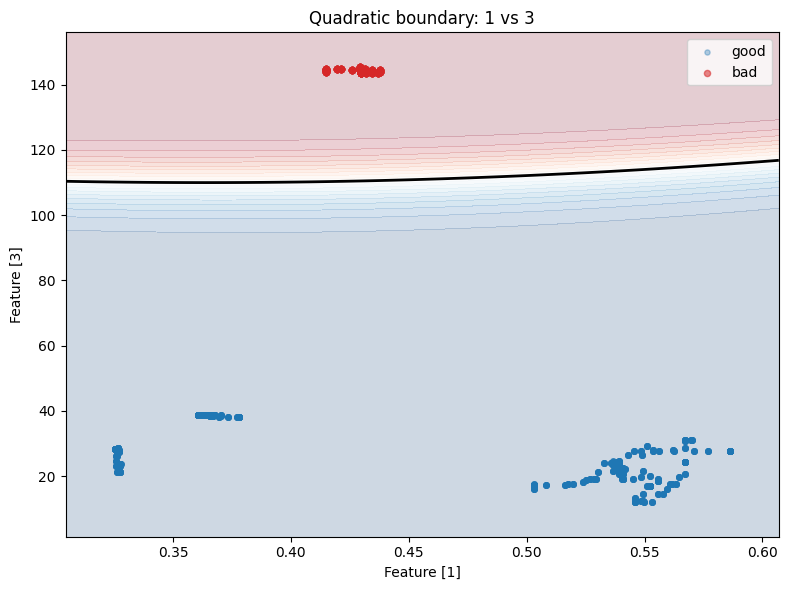

train accuracy: 1.0
Train ROC-AUC: 0.9999999999999999
CV ROC-AUC mean: 1.0
CV ROC-AUC std: 0.0
[[2743    0]
 [   0  345]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2743
           1       1.00      1.00      1.00       345

    accuracy                           1.00      3088
   macro avg       1.00      1.00      1.00      3088
weighted avg       1.00      1.00      1.00      3088



In [24]:
plot_decision_boundary(1, 3, model_type='linear')
plot_decision_boundary(1, 3, model_type='quadratic')

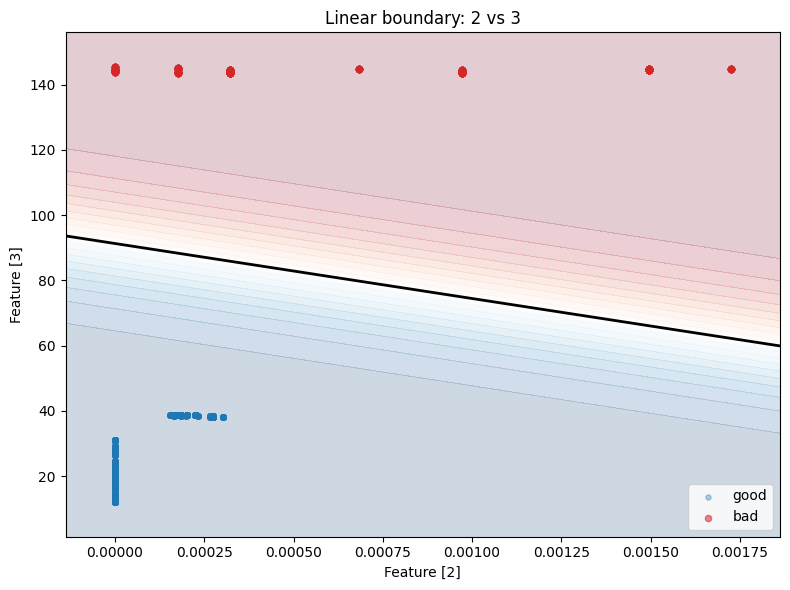

train accuracy: 1.0
Train ROC-AUC: 1.0
CV ROC-AUC mean: 1.0
CV ROC-AUC std: 0.0
[[2105    0]
 [   0  345]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2105
           1       1.00      1.00      1.00       345

    accuracy                           1.00      2450
   macro avg       1.00      1.00      1.00      2450
weighted avg       1.00      1.00      1.00      2450



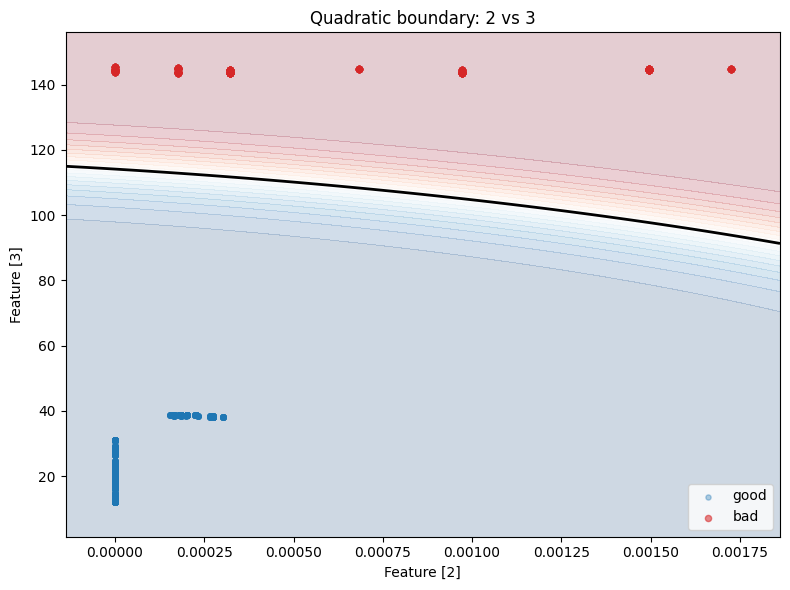

train accuracy: 1.0
Train ROC-AUC: 0.9999999999999999
CV ROC-AUC mean: 1.0
CV ROC-AUC std: 0.0
[[2105    0]
 [   0  345]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2105
           1       1.00      1.00      1.00       345

    accuracy                           1.00      2450
   macro avg       1.00      1.00      1.00      2450
weighted avg       1.00      1.00      1.00      2450



In [25]:
plot_decision_boundary(2, 3, model_type='linear')
plot_decision_boundary(2, 3, model_type='quadratic')

### 데이터 부족 한계 극복: LOOCV, RFE

데이터의 수가 부족하여 정확도가 1.0이 나오고 결과값에 대한 신뢰도가 높은 것 같지 않았다. 그래서 Overfitting이 발생하지 않으며 **데이터가 부족한 상황에서 판단 기준을 명확하고 정교하게 세우는 방식**으로 **LOOCV, RFE**를 사용하여 threshold를 다시 도출해보았다.



*   **LOOCV**: 데이터가 부족할 때 가용한 데이터를 최대한(N-1개) 학습에 활용하는 검증 방식.
*   **RFE**: 불필요한 '약한 지표'를 쳐내고, 판단 기준을 흐리지 않는 '진짜 핵심 지표'만 남기는 기법.



In [26]:
from sklearn.feature_selection import RFE
from sklearn.model_selection import LeaveOneOut

In [27]:
# 전체 지표를 활용한 LOOCV 검증 코드
# 데이터 한 개를 테스트로 두고 나머지로 학습하는 방식으로 모델 일반화 성능 평가

loo = LeaveOneOut()
y_true, y_pred = [], []
all_probabilities = []

print("🔄 6개 전체 지표 기반 LOOCV 검증 시작...")

for train_idx, test_idx in loo.split(X_summary):
    X_train, X_test = X_summary[train_idx], X_summary[test_idx]
    y_train, y_test = y_summary[train_idx], y_summary[test_idx]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            solver='liblinear',
            C=1.0,
            class_weight='balanced',
        ))
    ])
    model.fit(X_train, y_train)

    pred = model.predict(X_test)[0]
    prob = model.predict_proba(X_test)[0][1] # Bad(1)일 확률

    y_true.append(y_test[0])
    y_pred.append(pred)
    all_probabilities.append(prob)

loo_accuracy_all = accuracy_score(y_true, y_pred)
print(f"\n📊 전체 지표 LOOCV 최종 정확도: {loo_accuracy_all * 100:.2f}%")

# 전체 데이터로 최종 모델 학습 (새로운 데이터 판단용 가중치 확인)
final_model_all = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        solver='liblinear',
        C=1.0,
        class_weight='balanced',
    ))
])
final_model_all.fit(X_summary, y_summary)

classifier_all = final_model_all.named_steps['classifier']

print("\n🎯 [전체 지표 기준 모델 가중치(Weights)]")
for idx, name in feature_context.items():
    weight = classifier_all.coef_[0][idx]
    print(f" - {name} (지표 {idx}): {weight:.4f}")
print(f" - 절편 (Intercept): {classifier_all.intercept_[0]:.4f}")


🔄 6개 전체 지표 기반 LOOCV 검증 시작...

📊 전체 지표 LOOCV 최종 정확도: 100.00%

🎯 [전체 지표 기준 모델 가중치(Weights)]
 - 왼손목-왼어깨 거리 (지표 0): 1.6504
 - 양쪽 팔꿈치 거리 (지표 1): 0.9617
 - 왼손목 속도 (지표 2): 0.2901
 - 왼팔 각도 (지표 3): 2.1253
 - 오른팔 각도 (지표 4): 0.8042
 - 오른손목 각도 (지표 5): 0.7730
 - 절편 (Intercept): -4.4168


In [28]:
# RFE(Recursive Feature Elimination)로 핵심 지표를 선별하고
# LOOCV(Leave-One-Out Cross Validation)로 성능을 평가하는 코드
# 각 fold마다 feature selection을 다시 수행하여 데이터 누수(leakage)를 방지

loo = LeaveOneOut()
y_true, y_pred = [], []
selected_feature_counts = np.zeros(X_summary.shape[1], dtype=int)

print("Leakage 없는 RFE + LOOCV 검증 시작")

for train_idx, test_idx in loo.split(X_summary):
    # 학습/테스트 분리
    X_train, X_test = X_summary[train_idx], X_summary[test_idx]
    y_train, y_test = y_summary[train_idx], y_summary[test_idx]

    # 표준화 (학습 데이터 기준으로만 fit)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # RFE를 이용한 feature selection (각 fold마다 재학습)
    selector = RFE(
        estimator=LogisticRegression(
            solver='liblinear',
            class_weight='balanced',
        ),
        n_features_to_select=3,
    )

    selector.fit(X_train_scaled, y_train)

    # 선택된 feature 누적 카운트 (어떤 feature가 자주 선택되는지 확인)
    selected_feature_counts += selector.support_.astype(int)

    # 선택된 feature만 추출
    X_train_selected = selector.transform(X_train_scaled)
    X_test_selected = selector.transform(X_test_scaled)

    # 최종 모델 학습
    model = LogisticRegression(
        solver='liblinear',
        class_weight='balanced',
    )
    model.fit(X_train_selected, y_train)

    # 예측 결과 저장
    y_true.append(y_test[0])
    y_pred.append(model.predict(X_test_selected)[0])

# LOOCV 정확도 계산
loo_accuracy = accuracy_score(y_true, y_pred)
print(f"\nLOOCV + RFE 정확도: {loo_accuracy * 100:.2f}%")

# feature selection이 얼마나 자주 선택됐는지 출력
print("\nLOOCV fold별 feature 선택 빈도")
for idx, count in enumerate(selected_feature_counts):
    print(f" - [{idx}] {feature_context[idx]}: {count}/{len(X_summary)}")

Leakage 없는 RFE + LOOCV 검증 시작

LOOCV + RFE 정확도: 100.00%

LOOCV fold별 feature 선택 빈도
 - [0] 왼손목-왼어깨 거리: 3114/3114
 - [1] 양쪽 팔꿈치 거리: 0/3114
 - [2] 왼손목 속도: 0/3114
 - [3] 왼팔 각도: 3114/3114
 - [4] 오른팔 각도: 0/3114
 - [5] 오른손목 각도: 3114/3114


In [29]:
# 전체 데이터를 기반으로 최종 RFE를 수행하고,
# 선택된 핵심 feature로 최종 모델을 학습하는 단계
# (주의: 최종 모델은 학습용이므로 평가용 CV와 분리되어야 함)

# 스케일링 (전체 데이터 기준으로 fit)
final_rfe_scaler = StandardScaler()
X_scaled = final_rfe_scaler.fit_transform(X_summary)

# RFE를 이용해 핵심 feature 3개 선택
rfe = RFE(
    estimator=LogisticRegression(
        solver='liblinear',
        class_weight='balanced',
    ),
    n_features_to_select=3,
)

rfe.fit(X_scaled, y_summary)

# 선택된 feature 인덱스 추출
selected_features = [i for i, selected in enumerate(rfe.support_) if selected]
print(f"RFE로 선택된 핵심 feature 인덱스: {selected_features}")

# 각 feature의 중요도 순위 출력 (1이 가장 중요)
print(f"feature ranking 결과: {rfe.ranking_}")

# 선택된 feature만 사용하여 데이터 변환
X_selected = rfe.transform(X_scaled)

# 최종 Logistic Regression 모델 학습
final_rfe_model = LogisticRegression(
    solver='liblinear',
    class_weight='balanced',
)

final_rfe_model.fit(X_selected, y_summary)

RFE로 선택된 핵심 feature 인덱스: [0, 3, 5]
feature ranking 결과: [1 3 4 1 2 1]


LogisticRegression(class_weight='balanced', solver='liblinear')

## 새로운 데이터가 들어왔을 때 판단 로직

In [30]:
# 모든 feature를 고려했을 때의 예측 함수
# 입력된 새로운 데이터(1개의 샘플)에 대해 Bad 확률을 계산하고
# 구간별로 자세 상태를 분류 및 피드백을 반환

def predict_with_all_features(new_data_row, classifier, feature_context, threshold=0.5):
    """
    new_data_row: 6개 feature로 구성된 1개의 샘플
                  (30-step sequence는 summarize_sequence()로 미리 변환되어 있어야 함)
    classifier  : predict_proba를 지원하는 학습된 모델 (Pipeline 포함 가능)
    """

    new_data_row = np.asarray(new_data_row)

    # (1, feature_dim) 형태로 변환 (단일 샘플 예측용)
    new_data_reshaped = new_data_row.reshape(1, -1)

    # Bad(1) 클래스에 대한 확률 계산
    bad_probability = classifier.predict_proba(new_data_reshaped)[0][1]

    # 확률 구간에 따라 상태 분류
    if bad_probability < 0.15:
        case = "🟢 완벽한 자세 (안정)"
        feedback = "모든 신체 부위의 조화가 좋습니다. 현재 자세를 유지하세요."
    elif bad_probability < threshold:
        case = "🟡 주의 단계 (미세 흔들림)"
        feedback = "전체적인 틀은 맞지만 일부 지표가 경계에 있습니다."
    elif bad_probability < 0.85:
        case = "🟠 교정 필요 (경고)"
        feedback = "전체적인 신체 균형이 무너지기 시작했습니다."
    else:
        case = "🔴 심각한 변형 (위험)"
        feedback = "자세가 크게 무너졌습니다. 동작을 멈추고 정렬을 다시 잡으세요."

    return {
        "case": case,
        "bad_score": round(bad_probability * 100, 1),
        "feedback": feedback
    }

In [31]:
# RFE를 통해 선택된 핵심 지표만 사용하여 자세를 판단하는 함수
# 학습 시 사용한 scaler + RFE + classifier를 모두 동일하게 적용해야 함

def predict_new_pose(new_data_row, scaler, rfe_model, classifier, feature_context, threshold=0.5):
    """
    new_data_row: 6개 feature로 구성된 1개의 샘플
                  (30-step sequence는 summarize_sequence()로 변환된 상태여야 함)
    scaler      : RFE 이전 단계에서 사용한 StandardScaler
    rfe_model   : 학습된 RFE feature selector
    classifier  : RFE 이후 feature로 학습된 최종 분류 모델
    """

    new_data_row = np.asarray(new_data_row)

    # (1, feature_dim) 형태로 변환
    new_data_scaled = scaler.transform(new_data_row.reshape(1, -1))

    # RFE로 선택된 feature만 추출
    new_data_selected = rfe_model.transform(new_data_scaled)

    # Bad(1) 클래스 확률 계산
    bad_probability = classifier.predict_proba(new_data_selected)[0][1]

    # 상태 분류 로직
    if bad_probability < 0.15:
        case = "🟢 완벽한 자세 (안정)"
        feedback = "지표들이 모두 안정권입니다. 매우 좋은 자세를 유지하고 있습니다."
    elif bad_probability < threshold:
        case = "🟡 주의 단계 (미세 흔들림)"
        feedback = "자세의 틀은 유지되고 있으나 일부 지표가 경계에 있습니다."
    elif bad_probability < 0.85:
        case = "🟠 교정 필요 (경고)"
        feedback = "특정 신체 지표의 균형이 무너지기 시작했습니다. 핵심 feature를 점검하세요."
    else:
        case = "🔴 심각한 변형 (위험)"
        feedback = "자세가 크게 무너졌습니다. 즉시 동작을 중단하고 기본 정렬을 확인하세요."

    return {
        "case": case,
        "bad_score": round(bad_probability * 100, 1),
        "feedback": feedback
    }

In [32]:
# 테스트를 위한 새로운 데이터
# [왼손목-어깨 거리, 팔꿈치 거리, 왼손목 속도, 왼팔 각도, 오른팔 각도, 오른손목 각도]
# 여러 개의 신규 자세 데이터 (N행 6열)
new_samples = np.array([
    [0.25, 0.45, 0.00012, 85.5, 120.0, 95.0],
    [0.40, 0.60, 0.00050, 70.0, 140.0, 110.0],
    [0.18, 0.30, 0.00008, 92.0, 118.0, 88.0],
    [0.55, 0.80, 0.00120, 50.0, 160.0, 130.0],
    [0.22, 0.38, 0.00010, 89.0, 122.0, 91.0],
    [1.9481550e-01, 3.7792331e-01, 3.0180492e-04, 3.8152618e+01, 5.1025448e+01, 1.5915645e+02],
    [1.9481550e-01, 3.7792331e-01, 3.0180492e-04, 3.8152618e+01, 5.1025448e+01, 1.5915645e+02],
])

In [33]:
for idx, sample in enumerate(new_samples):

    # ==========================================
    # 1. Only LOOCV 모델로 예측 (6개 전체 지표 사용)
    # ==========================================
    result_all = predict_with_all_features(
        new_data_row=sample,
        classifier=final_model_all,
        feature_context=feature_context,
        threshold=0.5
    )

    # ==========================================
    # 2. RFE + LOOCV 모델로 예측 (핵심 지표만 사용)
    # ==========================================
    result_rfe = predict_new_pose(
        new_data_row=sample,
        scaler=final_rfe_scaler,
        rfe_model=rfe,
        classifier=final_rfe_model,
        feature_context=feature_context,
        threshold=0.5
    )

    # ==========================================
    # 3. 결과 비교 출력
    # ==========================================
    print("====== 🔍 전체 지표 기반 자세 판단 ======\n")
    print(f"[샘플 {idx+1}]")
    print(f"입력값: {sample}")
    print(f" ├─ 판단 결과: {result_all['case']}")
    print(f" ├─ 나쁜 자세 위험도: {result_all['bad_score']}%")
    print(f" └─ 피드백: {result_all['feedback']}")
    print("\n-----------------------------------\n")

    print("====== 🔍 RFE 핵심 지표 기반 자세 판단 ======\n")
    print(f"[샘플 {idx+1}]")
    print(f"입력값: {sample}")
    print(f" ├─ 판단 결과: {result_rfe['case']}")
    print(f" ├─ 나쁜 자세 위험도: {result_rfe['bad_score']}%")
    print(f" └─ 피드백: {result_rfe['feedback']}")
    print("\n-----------------------------------\n")


====== 🔍 전체 지표 기반 자세 판단 ======

[샘플 1]
입력값: [2.50e-01 4.50e-01 1.20e-04 8.55e+01 1.20e+02 9.50e+01]
 ├─ 판단 결과: 🟢 완벽한 자세 (안정)
 ├─ 나쁜 자세 위험도: 0.5%
 └─ 피드백: 모든 신체 부위의 조화가 좋습니다. 현재 자세를 유지하세요.

-----------------------------------

====== 🔍 RFE 핵심 지표 기반 자세 판단 ======

[샘플 1]
입력값: [2.50e-01 4.50e-01 1.20e-04 8.55e+01 1.20e+02 9.50e+01]
 ├─ 판단 결과: 🟢 완벽한 자세 (안정)
 ├─ 나쁜 자세 위험도: 0.0%
 └─ 피드백: 지표들이 모두 안정권입니다. 매우 좋은 자세를 유지하고 있습니다.

-----------------------------------

====== 🔍 전체 지표 기반 자세 판단 ======

[샘플 2]
입력값: [4.0e-01 6.0e-01 5.0e-04 7.0e+01 1.4e+02 1.1e+02]
 ├─ 판단 결과: 🟡 주의 단계 (미세 흔들림)
 ├─ 나쁜 자세 위험도: 39.2%
 └─ 피드백: 전체적인 틀은 맞지만 일부 지표가 경계에 있습니다.

-----------------------------------

====== 🔍 RFE 핵심 지표 기반 자세 판단 ======

[샘플 2]
입력값: [4.0e-01 6.0e-01 5.0e-04 7.0e+01 1.4e+02 1.1e+02]
 ├─ 판단 결과: 🟢 완벽한 자세 (안정)
 ├─ 나쁜 자세 위험도: 0.4%
 └─ 피드백: 지표들이 모두 안정권입니다. 매우 좋은 자세를 유지하고 있습니다.

-----------------------------------

====== 🔍 전체 지표 기반 자세 판단 ======

[샘플 3]
입력값: [1.80e-01 3.00e-01 8.00e-05 9.20e+01 1.18e+02 8.80e

## 설명가능한 피드백


피드백을 주는 과정에서 어떤 feature에서 문제가 발생하는지 그리고 어느 정도인지를 파악해서 피드백을 주는 방식이 나을 것 같아 내용을 수정하였다.

> 단순히 bad 확률만 주는 게 아니라 **어떤 feature가 위험도를 올렸는지 설명 가능한 피드백을 만드는 것**

이미 LogisticRegression을 쓰고 있어 `위험도 = feature 값 * weight` 구조여서 각 feature 기여도를 계산하기 쉽다.


`contribution = feature_value * model_weight`

값이 클수록:
*   자세 붕괴에 크게 기여
*   위험도 상승 원인



출력 예시

```
🟠 교정 필요 (경고)

위험도: 72.3%

주요 문제 부위:
1. 오른팔 각도 → 위험 기여도 34%
2. 왼손목 속도 → 위험 기여도 27%
3. 팔꿈치 거리 → 위험 기여도 18%

피드백:
- 오른팔이 과도하게 벌어지고 있습니다.
- 손목 움직임이 불안정합니다.
- 팔 간격이 무너지고 있습니다.
```



Bad 확률 + 문제 feature + 정상 범위 대비 얼마나 벗어났는지 + 위험 기여도 % + 실시간 코칭

In [34]:
# pipeline 모델 학습
pipeline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        solver='liblinear',
        class_weight='balanced',
    ))
])

pipeline_model.fit(X_summary, y_summary)


Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(class_weight='balanced',
                                    solver='liblinear'))])

In [35]:
# 정상 자세 기준 통계 생성
good_samples = X_summary[y_summary == 0]

feature_mean = np.mean(good_samples, axis=0)
feature_std = np.std(good_samples, axis=0)

In [36]:
# feature별 위험 방향 정의
# =========================
# high: 값이 커질수록 위험
# low : 값이 작아질수록 위험
# both: 양 방향 모두 위험

feature_directions = {
    0: "both",
    1: "both",
    2: "high",
    3: "both",
    4: "high",
    5: "both"
}

In [37]:
# feature별 피드백
feature_feedback = {
    0: "왼손과 어깨 간 정렬이 무너지고 있습니다.",
    1: "양 팔의 간격 균형이 깨지고 있습니다.",
    2: "손목 움직임이 과도하게 흔들리고 있습니다.",
    3: "왼팔 각도가 비정상적으로 변형되고 있습니다.",
    4: "오른팔이 과도하게 벌어지고 있습니다.",
    5: "오른손목 정렬이 무너지고 있습니다."
}

In [38]:
# 자동 코칭 시스템
coaching_rules = {
    0: lambda z: "왼손 위치를 몸 중심 방향으로 안정화하세요.",
    1: lambda z: "양 팔 간격을 일정하게 유지하세요.",
    2: lambda z: "손목에 힘이 들어가 흔들림이 커지고 있습니다.",
    3: lambda z: "왼팔 각도를 일정하게 유지하세요.",
    4: lambda z: "오른팔이 과도하게 벌어지고 있습니다.",
    5: lambda z: "오른손목 정렬이 틀어지고 있습니다."
}

In [39]:
# 위험 방향 고려한 z-score 평가
def compute_directional_risk(idx, z):

    direction = feature_directions[idx]

    if direction == "high":
        return max(0, z)

    elif direction == "low":
        return max(0, -z)

    else:
        return abs(z)

In [40]:
# z-score 상태 분류
def classify_deviation(risk_z):

    if risk_z < 1:
        return "정상"

    elif risk_z < 2:
        return "주의"

    elif risk_z < 3:
        return "위험"

    else:
        return "심각"

최종 posture score =
0.6 ? classifier probability
+
0.4 ? biomechanical risk


In [41]:
# Hybrid posture scoring
def compute_hybrid_score(
    classifier_probability,
    biomechanical_risk
):

    # classifier 기반 위험도
    global_risk = classifier_probability * 100

    # biomechanical risk scaling
    biomech_score = min(100, biomechanical_risk * 20)

    # hybrid score
    final_score = (
        0.6 * global_risk
        +
        0.4 * biomech_score
    )

    return final_score

In [42]:
# 최종 posture 상태 결정
def determine_posture_case(
    final_score,
    severe_count,
    danger_count,
):

    # feature override
    if severe_count >= 1:
        return "🔴 위험"

    if danger_count >= 2:
        return "🔴 위험"

    # hybrid score 기준
    if final_score < 30:
        return "🟢 안정"

    elif final_score < 60:
        return "🟡 불안정"

    else:
        return "🔴 위험"

In [43]:
# explainable posture analysis
def explain_posture(sample):

    sample = np.asarray(sample)

    scaler = pipeline_model.named_steps['scaler']
    classifier = pipeline_model.named_steps['classifier']

    # scaling
    scaled_sample = scaler.transform(
        sample.reshape(1, -1)
    )[0]

    # classifier probability
    bad_prob = pipeline_model.predict_proba(
        sample.reshape(1, -1)
    )[0][1]

    weights = classifier.coef_[0]

    explanations = []
    biomechanical_risk = 0
    severe_count = 0
    danger_count = 0

    # =====================================================
    # feature ??
    # =====================================================

    for idx in range(len(sample)):

        # raw z-score
        z = (
            sample[idx] - feature_mean[idx]
        ) / (feature_std[idx] + 1e-8)

        # ??? ?? ?? z-score
        directional_risk = compute_directional_risk(idx, z)

        # ??
        status = classify_deviation(directional_risk)

        # LogisticRegression? bad class logit? ?? ??? feature ???
        contribution = scaled_sample[idx] * weights[idx]
        bad_contribution = max(0, contribution)

        biomechanical_risk += directional_risk

        # ?? feature count
        if status == "??":
            severe_count += 1

        elif status == "??":
            danger_count += 1

        explanations.append({
            "feature": feature_context[idx],
            "value": sample[idx],
            "z_score": z,
            "risk_z": directional_risk,
            "status": status,
            "contribution": contribution,
            "bad_contribution": bad_contribution,
            "warning": feature_feedback[idx],
            "coaching": (
                coaching_rules[idx](z)
                if directional_risk >= 2
                else None
            )
        })

    # =====================================================
    # contribution %
    # =====================================================

    total_bad_contribution = sum(
        item["bad_contribution"]
        for item in explanations
    )

    for item in explanations:

        item["risk_percent"] = (
            item["bad_contribution"]
            /
            (total_bad_contribution + 1e-8)
        ) * 100

    explanations = sorted(
        explanations,
        key=lambda x: (x["risk_z"], x["bad_contribution"]),
        reverse=True
    )

    # =====================================================
    # Hybrid score 계산
    # =====================================================

    final_score = compute_hybrid_score(
        bad_prob,
        biomechanical_risk
    )

    # =====================================================
    # 최종 posture 상태
    # =====================================================

    posture_case = determine_posture_case(
        final_score,
        severe_count,
        danger_count,
    )

    return {
        "case": posture_case,
        "final_score": final_score,
        "classifier_probability": bad_prob * 100,
        "biomechanical_risk": biomechanical_risk,
        "details": explanations
    }


In [44]:
for idx, sample in enumerate(new_samples):

    result = explain_posture(sample)

    print("\n====================================================")
    print(f"🎻 샘플 {idx+1} 자세 분석")
    print("====================================================")

    print(
        f"\n{result['case']} "
        f"({result['final_score']:.1f}점)"
    )

    print("\n[Hybrid Scoring]")

    print(
        f"- Classifier 위험도: "
        f"{result['classifier_probability']:.1f}%"
    )

    print(
        f"- Biomechanical 위험도: "
        f"{result['biomechanical_risk']:.2f}"
    )

    print(
        f"- 최종 자세 점수: "
        f"{result['final_score']:.1f}"
    )

    print("\n[위험 분석]")

    # 상위 위험 feature 3개
    for rank, item in enumerate(result['details'][:3], start=1):

        print(f"\n{rank}. {item['feature']}")

        print(
            f"   - 위험도 기여: "
            f"{item['risk_percent']:.1f}%"
        )

        print(
            f"   - 정상 대비: "
            f"{item['z_score']:+.2f}σ"
        )

        print(
            f"   - 상태: "
            f"{item['status']}"
        )

    print("\n[실시간 코칭]")

    coaching_exist = False

    for item in result['details'][:3]:

        if item['coaching'] is not None:

            print(f"- {item['coaching']}")
            coaching_exist = True

    if not coaching_exist:
        print("- 현재 자세는 안정적으로 유지되고 있습니다.")


🎻 샘플 1 자세 분석

🟡 불안정 (40.3점)

[Hybrid Scoring]
- Classifier 위험도: 0.5%
- Biomechanical 위험도: 22.42
- 최종 자세 점수: 40.3

[위험 분석]

1. 오른손목 각도
   - 위험도 기여: 0.0%
   - 정상 대비: -9.18σ
   - 상태: 심각

2. 왼팔 각도
   - 위험도 기여: 52.5%
   - 정상 대비: +7.82σ
   - 상태: 심각

3. 왼손목-왼어깨 거리
   - 위험도 기여: 27.3%
   - 정상 대비: +3.30σ
   - 상태: 심각

[실시간 코칭]
- 오른손목 정렬이 틀어지고 있습니다.
- 왼팔 각도를 일정하게 유지하세요.
- 왼손 위치를 몸 중심 방향으로 안정화하세요.

🎻 샘플 2 자세 분석

🔴 위험 (63.5점)

[Hybrid Scoring]
- Classifier 위험도: 39.2%
- Biomechanical 위험도: 24.44
- 최종 자세 점수: 63.5

[위험 분석]

1. 왼손목-왼어깨 거리
   - 위험도 기여: 44.7%
   - 정상 대비: +7.45σ
   - 상태: 심각

2. 오른손목 각도
   - 위험도 기여: 0.0%
   - 정상 대비: -6.86σ
   - 상태: 심각

3. 왼팔 각도
   - 위험도 기여: 20.1%
   - 정상 대비: +5.78σ
   - 상태: 심각

[실시간 코칭]
- 왼손 위치를 몸 중심 방향으로 안정화하세요.
- 오른손목 정렬이 틀어지고 있습니다.
- 왼팔 각도를 일정하게 유지하세요.

🎻 샘플 3 자세 분석

🟡 불안정 (40.0점)

[Hybrid Scoring]
- Classifier 위험도: 0.0%
- Biomechanical 위험도: 23.83
- 최종 자세 점수: 40.0

[위험 분석]

1. 오른손목 각도
   - 위험도 기여: 0.0%
   - 정상 대비: -10.26σ
   - 상태: 심각

2. 왼팔 각도
   - 위험도 기여: 71.8%
   - 정상 

### 자세 점수 로직

**6개 feature를 조합한 '자세 점수' 로직**

"왼손목 거리 차이"와 "왼팔 각도"를 결합하면 훨씬 고도화된 피드백이 가능.

- Case A (안정적): 왼팔 각도가 정상 범위 내에 있고, 왼손목 거리 차이가 작음 → "완벽합니다!"
- Case B (불안정): 왼팔 각도는 정상인데, 왼손목 거리 차이가 큼 → "팔꿈치는 고정되었으나 손목이 흔들립니다."
- Case C (자세 무너짐): 왼팔 각도가 범위를 벗어나면서 손목 거리 차이도 커짐 → "전체적인 자세가 무너졌습니다. 어깨와 팔의 힘을 빼세요."